# Introdução

Aluno: Igor Sales Bezerra Souza         Matricula: 24/2105226

Esta ativdade tem o objetivo de implementar a resolução de sistemas lineares através de métodos numéricos em problemas de engenharia, como estudo de concentração em diferentes reatores de mistura e o campo 1D de temperatura de um combustível sólido como tratado no [Programa 5](Programa_5.pdf). 

# Problema 1

Resolução do problema de concentração dos reatores de mistura. O problema busca encontrar a concentração em cada um dos cinco reatores de c1 até c5

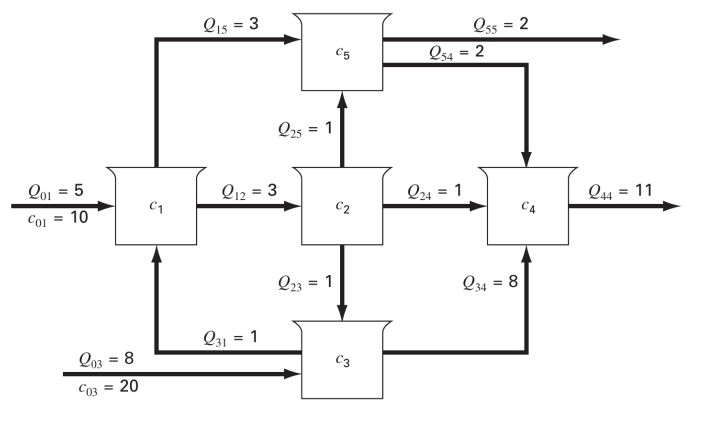

In [1]:
Q01 = 5
Q03 = 8

Q12 = 3
Q15 = 3
Q31 = 1
Q23 = 1
Q24 = 1
Q25 = 1
Q34 = 8
Q44 = 11
Q54 = 2
Q55 = 2

c01 = 10
c03 = 20

In [2]:
S = [[(Q12+Q15), 0, -Q31, 0, 0],
     [-Q12, (Q23+Q24+Q25), 0, 0, 0],
     [0, -Q23, (Q31+Q34), 0, 0],
     [0, -Q24, -Q34, Q44, -Q54],
     [-Q15, -Q25, 0, 0, (Q54+Q55)]]

F = [Q01*c01,
     0,
     Q03*c03,
     0,
     0]

## Definição das funções necessáriais para resolução do problema 1

In [3]:
def lu_decomposition(A):
    """
    Realiza a decomposição LU de uma matriz quadrada A.

    A matriz A é decomposta como A = L * U, onde:
    - L é uma matriz triangular inferior com diagonal principal igual a 1.
    - U é uma matriz triangular superior.

    Parâmetros:
    A : Matriz quadrada (n x n) a ser decomposta.

    Retorna:
    L : Matriz triangular inferior (n x n).
    U : Matriz triangular superior (n x n).
    """
    n = len(A)
    L = [[0.0] * n for _ in range(n)]
    U = [[0.0] * n for _ in range(n)]

    for i in range(n):
        for k in range(i, n):
            sum_ = sum(L[i][j] * U[j][k] for j in range(i))
            U[i][k] = A[i][k] - sum_

        for k in range(i, n):
            if i == k:
                L[i][i] = 1.0
            else:
                sum_ = sum(L[k][j] * U[j][i] for j in range(i))
                L[k][i] = (A[k][i] - sum_) / U[i][i]

    return L, U


def forward_substitution(L, b):
    """
    Resolve o sistema Ly = b por substituição progressiva.

    Supõe que L é uma matriz triangular inferior com elementos não-nulos na diagonal.

    Parâmetros:
    L :     Matriz triangular inferior (n x n).
    b : Vetor do lado direito (n).

    Retorna:
    y : Solução intermediária do sistema (n).
    """
    n = len(L)
    y = [0.0] * n
    for i in range(n):
        y[i] = b[i] - sum(L[i][j] * y[j] for j in range(i))
    return y


def backward_substitution(U, y):
    """
    Resolve o sistema Ux = y por substituição regressiva.

    Supõe que U é uma matriz triangular superior com elementos não-nulos na diagonal.

    Parâmetros:
    U : Matriz triangular superior (n x n).
    y : Vetor do lado direito (n), resultado da substituição progressiva.

    Retorna:
    x : Solução final do sistema (n).
    """
    n = len(U)
    x = [0.0] * n
    for i in reversed(range(n)):
        x[i] = (y[i] - sum(U[i][j] * x[j] for j in range(i + 1, n))) / U[i][i]
    return x


## Resultado

In [4]:
L, U = lu_decomposition(S)

y = forward_substitution(L, F)

x = backward_substitution(U, y)

print(f'C1 = {x[0]:.2f}\nC2 = {x[1]:.2f}\nC3 = {x[2]:.2f}\nC4 = {x[3]:.2f}\nC5 = {x[4]:.2f}\n')

C1 = 11.51
C2 = 11.51
C3 = 19.06
C4 = 17.00
C5 = 11.51



# Problema 2

O problema 2 consiste em estudar a variação de temperatura relacionando espaço e tempo (Avaliando o comportamento transiente) de um combustível sólido

Não consegui resolver o problema de forma satisfatória a tempo da data limite da atividade. Mas vou continuar tentado resolver o problema nos próximos dias

In [5]:
import numpy as np

In [6]:
def thomas_metod(M,R):

    ds = [0]*len(M)
    dp = [0]*len(M)
    di = [0]*len(M)
    e = [0]*len(M)
    
    x = [0]*len(M)

    c = 0
    n = len(M)-1


    for i in range(len(M)):
        for j in range(len(M[0])):
            if i == j: 
                dp[c] = M[i][j]
                if j<len(M[0])-1:
                    ds[c] = M[i][j+1]
                if j>0:
                    di[c] = M[i][j-1]
                c += 1

    f = [dp[0]]*len(M)
    r = R

    # Decomposição 
    for k in range(1,len(M)):
        e[k] = di[k]/f[k-1]
        f[k] = dp[k] - e[k]*ds[k-1]
    
    # Substuição progressiva
    for k in range(1,len(M)):
        r[k] = r[k] - e[k]*r[k-1]
    
    # Substituição regressiva

    x[n] = r[n]/f[n]

    for k in range(n-1, -1 , -1):
        x[k] = (r[k]-ds[k]*x[k+1])/f[k]

    return x 


In [18]:
n = 7

delta_t = 0.1

k = 30

l = 0.010/n

alpha = 5*10**(-6)

Fo = alpha*delta_t/l**2

h = 1100

Bi = h*l/k

q_dot = 10**7

A_c = q_dot/(alpha*k)

T = [25]*n

T_inf = 25

T_array = np.array(T)


In [8]:

# T1 = 25 + 275.15
# T2 = 25 + 275.15
# T3 = 25 + 275.15
# T4 = 25 + 275.15
# T5 = 25 + 275.15
# T6 = 25 + 275.15
# T7 = 25 + 275.15

# T_inf = 250 + 275.15

# M = [[(1+2*Fo), -2*Fo, 0, 0, 0, 0, 0],
#      [-Fo, (1+2*Fo), -Fo, 0, 0, 0, 0],
#      [0, -Fo, (1+2*Fo), -Fo, 0, 0, 0],
#      [0, 0, -Fo, (1+2*Fo), -Fo, 0, 0],
#      [0, 0, 0, -Fo, (1+2*Fo), -Fo, 0],
#      [0, 0, 0, 0, -Fo, (1+2*Fo), -Fo],
#      [0, 0, 0, 0, 0, -2*Fo, (1+2*Fo+2*Fo*Bi)]]


# R = [T1+A*delta_t, T2+A*delta_t, T3+A*delta_t, T4+A*delta_t, T5+A*delta_t, T6+A*delta_t, T7+Fo*(2*Bi*T_inf+q_dot*l**2/k)]

In [9]:
def Matriz_sistema(n, Fo, Bi):
    A = np.zeros((n, n))

    for i in range(n):
        if i == 0:
            A[i, i] = 1 + 2 * Fo
            A[i, i + 1] = -2 * Fo
        elif i == n - 1:
            A[i, i] = 1 + 2 * Fo + 2 * Fo * Bi
            A[i, i - 1] = -2 * Fo
        else:
            A[i, i - 1] = -Fo
            A[i, i] = 1 + 2 * Fo
            A[i, i + 1] = -Fo
    return A

def termos_fonte(n,T, A, delta_t, Fo, Bi, T_inf, q_dot, l, k):
    """
    Constrói o vetor V com base no padrão do vetor R.

    T: ndarray com 101 temperaturas (T0 a T100)
    A, delta_t, Fo, Bi, T_inf, q_dot, l, k: constantes físicas
    """
    V = np.zeros(n)

    # Primeiros 100 termos: Ti + A * delta_t
    V[:-1] = T[:-1] + A * delta_t

    # Último termo especial
    V[-1] = T[-1] + Fo * (2 * Bi * T_inf + q_dot * l**2 / k)

    return V

In [21]:
Bi

0.05238095238095238

In [19]:
M = Matriz_sistema(n, Fo, Bi)
R = termos_fonte(n,T_array, A_c, delta_t, Fo, Bi, T_inf, q_dot, l, k)

In [20]:
thomas_metod(M,R)


[6666443264.830312,
 6665987291.694892,
 6662758257.450176,
 6643576430.4850855,
 6530148639.513533,
 5859504309.141423,
 1894319641.9315794]